In [1]:
import matplotlib.pyplot as plt
import json
import numpy as np

In [2]:
def plot_loss_curves(loss_data, save_dir=None):
    """Plot training and validation loss curves as separate figures"""
    train_energy_loss = loss_data['train_energy_losses']
    epochs = list(range(len(train_energy_loss)))
    # Plot 1: Training Loss Components
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_energy_loss, label='Training Energy Loss', linewidth=2, color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Mean Energy Loss (W/m³)')
    #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
 
    plt.show()

In [3]:
def load_loss_data(json_path):
    """Load previously saved loss data"""
    
    with open(json_path, 'r') as f:
        loss_data = json.load(f)
    print(f"Loss data loaded from {json_path}")
    return loss_data

In [6]:
def combine_training_results(file_paths, output_file):
    """Combine multiple training session JSON files"""
    
    # Initialize combined data structure
    combined = {
        'train_energy_losses': [],
    }
    
    # Load and combine all files
    for file_path in file_paths:
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # Append data from each file
        combined['train_energy_losses'].extend(data['train_energy_losses'])
        
    
    # Save combined results
    with open(output_file, 'w') as f:
        json.dump(combined, f, indent=4)
    
    print(f"Combined {len(file_paths)} files. Results saved to {output_file}")
    return combined

file_list = [
    "D:/Results/Energy loss 2/loss_data1.json",
    "D:/Results/Energy loss 2/loss_data2.json",
    "D:/Results/Energy loss 2/loss_data3.json",
]

combined_data = combine_training_results(file_list, "D:/Results/Energy loss 2/combined.json")

Combined 3 files. Results saved to D:/Results/Energy loss 2/combined.json


Loss data loaded from D:/Results/Energy_Loss/combined.json


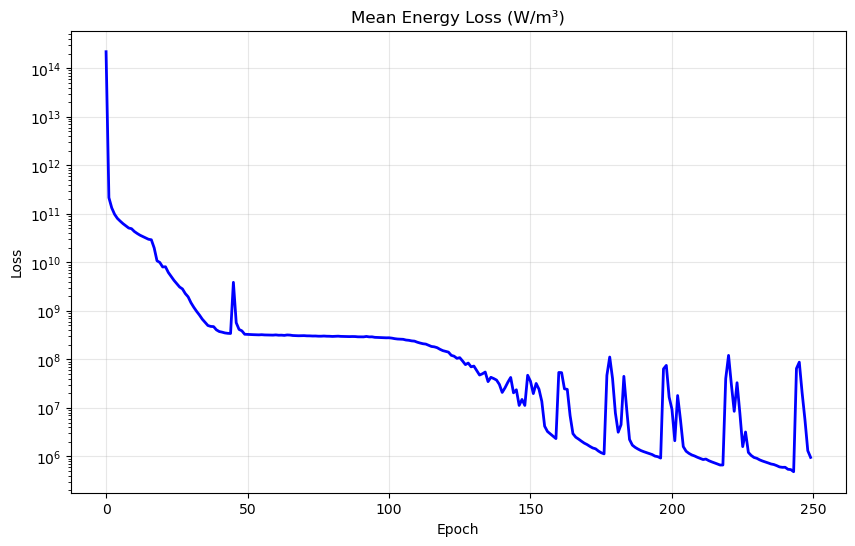

In [4]:
results_dir = "D:/Results/Energy_Loss/combined.json"
combined_data = load_loss_data(results_dir)
plot_loss_curves(combined_data)

Loss data loaded from D:/Results/Energy loss 2/combined.json


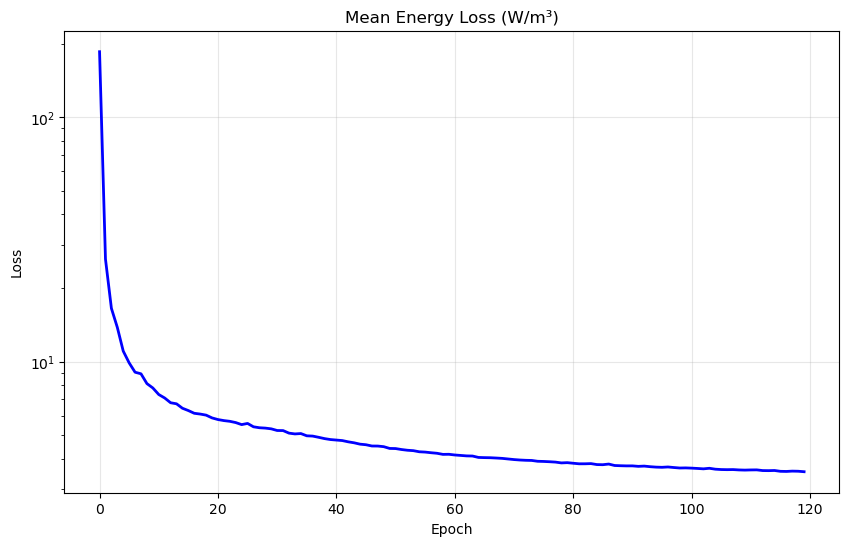

In [7]:
results_dir = "D:/Results/Energy loss 2/combined.json"
loss_data = load_loss_data(results_dir)
plot_loss_curves(combined_data)